<h1 style="text-align:center; 
           background:rgb(139, 217, 144); 
           color: rgb(4, 82, 9);
           font-size:45px; 
           padding:20px;
           border-radius:12px;">
     <b> Future Stock Prediction</b>
</h1>

### <b>🧑‍💼 Project Author</b>

***Author: Muhammad Usman***

***Artificial Intelligence/Machine Learning/DataEngineering Enthusiast***

***Date: MAY 2026***

<h2 style="text-align:center; 
           background: rgb(139, 217, 144);  
           color:rgb(4, 82, 9); 
           font-size:42px; 
           padding:12px;
           border-radius:12px;
           display: inline-block">
     <b> Step 0: Creating Environment(venv)</b>
</h2>



<h2 style="text-align:center; 
           background: rgb(139, 217, 144);  
           color:rgb(4, 82, 9); 
           font-size:42px; 
           padding:12px;
           border-radius:12px;
           display: inline-block">
     <b> Step 1: PIP & Importing Libraries</b>
</h2>




In [1]:
# Libraries for Data Manipulation
import pandas as pd
import numpy as np

# libraries for Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# plt.style.use('seaborn')
# sns.set_palette("husl")
import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.offline as pyo
pyo.init_notebook_mode(connected=True)

# This warnings filter is used to ignore any warnings that may arise during the execution of the code, 
# which can help to keep the output clean and focused on the results.
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf

<h2 style="text-align:center; 
           background: rgb(139, 217, 144);  
           color:rgb(4, 82, 9); 
           font-size:42px; 
           padding:12px;
           border-radius:12px;
           display: inline-block">
     <b> Step 2: Data Loading | Exploring  | Cleaning</b>
</h2>




In [3]:
# loading data for Apple and Tesla stocks from Yahoo Finance using the `yfinance library`. The data is downloaded for the period from January 1, 2010, to April 30, 2026.
data_aapl = yf.download('AAPL', start='2010-01-01', end='2026-05-13')
# data_tsla = yf.download('TSLA', start='2010-01-01', end='2026-04-30')

[*********************100%***********************]  1 of 1 completed


In [9]:
# Can see random rows of the dataset, which is useful for getting a quick overview.
data_aapl.sample(5)

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2013-06-17,13.222021,13.335265,13.171827,13.204882,259414400
2015-03-06,28.150597,28.766529,28.074996,28.550841,291368400
2015-07-16,28.694654,28.708055,28.435642,28.522724,144889600
2011-06-03,10.290494,10.347124,10.247647,10.282704,313250000
2016-04-25,23.798565,23.927659,23.669471,23.780446,112126400


In [10]:
# Overall dataset information, including the number of entries, column names, data types, and memory usage.
data_aapl.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4112 entries, 2010-01-04 to 2026-05-08
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   4112 non-null   float64
 1   (High, AAPL)    4112 non-null   float64
 2   (Low, AAPL)     4112 non-null   float64
 3   (Open, AAPL)    4112 non-null   float64
 4   (Volume, AAPL)  4112 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 192.8 KB


In [11]:
data_aapl.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,4112.000000,4112.000000,4112.000000,4112.000000,4.112000e+03
mean,81.407837,82.217061,80.525909,81.343020,2.153276e+08
std,78.877301,79.651889,78.028456,78.800754,2.146214e+08
min,5.754395,5.872748,5.700461,5.763982,1.791060e+07
25%,18.471127,18.674391,18.376822,18.505897,7.558635e+07
50%,40.108810,40.513962,39.705095,40.106792,1.281770e+08
75%,145.988258,147.612739,144.535589,145.790717,2.839660e+08
max,293.320007,294.760010,290.000000,290.010010,1.880998e+09


In [12]:
# checking duplicate values
data_aapl.duplicated().sum()

np.int64(0)

> Hurra No Duplicated and no null values in the dataset!

In [13]:
# Checking columns dimensions

print(data_aapl.columns)

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


> this is multi-index columnns, as we use yfinance to download data, it creates multi-index columns with two levels. 

In [ ]:
# data_aapl.columns = data_aapl.columns.droplevel(1)
                     
# data_aapl.head()

# do not run above code again as it will cause and errror in the next cells


Price,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,6.412382,6.427063,6.363542,6.395003,493729600
2010-01-05,6.423470,6.459725,6.389611,6.430062,601904800
2010-01-06,6.321296,6.448939,6.314704,6.423470,552160000
2010-01-07,6.309609,6.352157,6.263766,6.344666,477131200
2010-01-08,6.351558,6.352157,6.264067,6.301220,447610800


<Axes: xlabel='Price', ylabel='Price'>

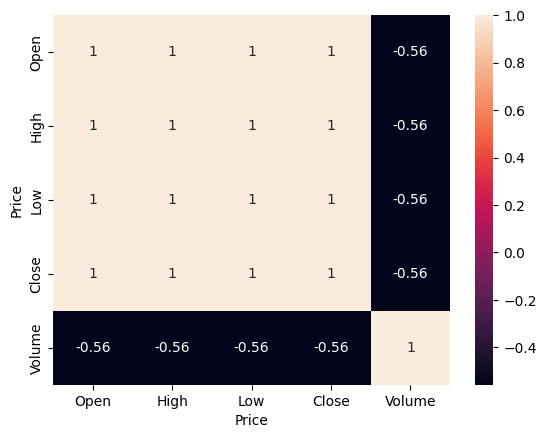

In [15]:
sns.heatmap(data_aapl[['Open','High','Low','Close','Volume']].corr(), annot=True)

<h2 style="text-align:center; 
           background: rgb(139, 217, 144);  
           color:rgb(4, 82, 9); 
           font-size:42px; 
           padding:12px;
           border-radius:12px;
           display: inline-block">
     <b> Date Time Series</b>
</h2>




In [16]:
# for AAPL dataset, we are creating new columns to extract temporal features from the date index.

data_aapl['Year'] = data_aapl.index.year
data_aapl['Month'] = data_aapl.index.month_name()
data_aapl['Day'] = data_aapl.index.day_name()
data_aapl['IsYearStart'] = data_aapl.index.is_year_start.astype(int)
data_aapl['IsYearEnd'] = data_aapl.index.is_year_end.astype(int)

In [21]:
data_aapl.sample(1)

Price,Close,High,Low,Open,Volume,Year,Month,Day,IsYearStart,IsYearEnd
Date,,,,,,,,,,
2016-12-12,26.089586,26.481044,25.903066,26.087283,105497600,2016,December,Monday,0,0


In [23]:
# Visualize the closing prices of AAPL and TSLA over time using Plotly.

fig = go.Figure()
fig.add_trace(go.Scatter(x=data_aapl.index, y=data_aapl[('Open')], mode='lines', name='AAPL'))
# fig.add_trace(go.Scatter(x=data_tsla.index, y=data_tsla[('Open')], mode='lines', name='TSLA'))
fig.update_layout(title='AAPL Opening Prices', xaxis_title='Date', yaxis_title='Open Price')
fig.show()

In [24]:
# Visualize the closing prices of AAPL and TSLA over time using Plotly.

fig = go.Figure()
fig.add_trace(go.Scatter(x=data_aapl.index, y=data_aapl[('Close')], mode='lines', name='AAPL'))
# fig.add_trace(go.Scatter(x=data_tsla.index, y=data_tsla[('Close')], mode='lines', name='TSLA'))
fig.update_layout(title='AAPL Closing Prices', xaxis_title='Date', yaxis_title='Close Price')
fig.show()


### <b>Observation</b>
---

- According to the both graphs of opening and closing (AAPL #and TSLA), we can see that both stocks have shown significant growth over the years, with some periods of volatility. 

- AAPL has generally been more stable compared to TSLA, which has experienced more dramatic fluctuations in price. 

- Both stocks have seen a substantial increase in value, especially in recent years, indicating strong performance in the stock market.

<h2 style="text-align:center; 
           background: rgb(139, 217, 144);  
           color:rgb(4, 82, 9); 
           font-size:42px; 
           padding:12px;
           border-radius:12px;
           display: inline-block">
     <b> Feature Engineering </b>
</h2>


## <b>Daily Returns Calculation (Percentage Change in Stock Price)</b>

> Formula: (Current Close - Previous Close) / Previous Close

> This helps measure how much the stock price changes daily in percentage terms

> Useful for understanding growth rate and volatility

In [25]:
data_aapl['Returns'] = data_aapl['Close'].pct_change()
data_aapl['Returns (%)'] = data_aapl['Returns'] * 100

In [26]:
data_aapl

Price,Close,High,Low,Open,Volume,Year,Month,Day,IsYearStart,IsYearEnd,Returns,Returns (%)
Date,,,,,,,,,,,,
2010-01-04,6.412382,6.427063,6.363542,6.395003,493729600,2010,January,Monday,0,0,NaN,NaN
2010-01-05,6.423470,6.459725,6.389611,6.430062,601904800,2010,January,Tuesday,0,0,0.001729,0.172921
2010-01-06,6.321296,6.448939,6.314704,6.423470,552160000,2010,January,Wednesday,0,0,-0.015906,-1.590633
2010-01-07,6.309609,6.352157,6.263766,6.344666,477131200,2010,January,Thursday,0,0,-0.001849,-0.184887
2010-01-08,6.351558,6.352157,6.264067,6.301220,447610800,2010,January,Friday,0,0,0.006648,0.664840
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-04,276.829987,280.630005,274.859985,279.660004,46668400,2026,May,Monday,0,0,-0.011816,-1.181562
2026-05-05,284.179993,284.570007,276.500000,276.929993,49311700,2026,May,Tuesday,0,0,0.026551,2.655061
2026-05-06,287.510010,288.029999,281.070007,281.920013,58336100,2026,May,Wednesday,0,0,0.011718,1.171799


In [27]:
# analyzing highest lost and gain in AAPL stock
max_gain = data_aapl['Returns (%)'].max()
max_loss = data_aapl['Returns (%)'].min()

fig = go.Figure(data=[go.Bar(x=['Max Gain', 'Max Loss'], y=[max_gain, max_loss], marker_color=['green', 'red'])])
fig.update_layout(title='Maximum Gain and Loss in AAPL Stock', xaxis_title='Type', yaxis_title='Returns (%)')
fig.show()


<Axes: xlabel='Returns', ylabel='Count'>

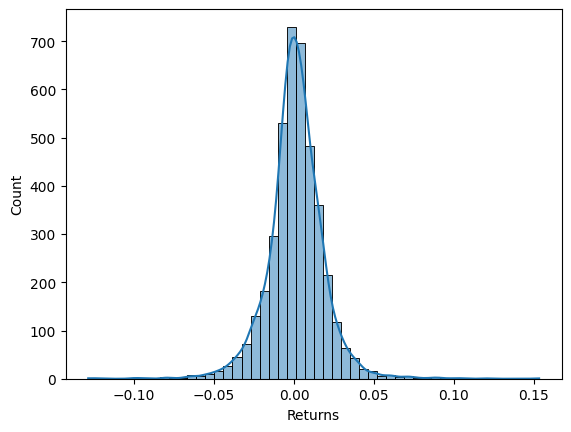

In [28]:
sns.histplot(data_aapl['Returns'].dropna(), bins=50, kde=True)

# <b>Observation</b>
---
- The first value in the `Returns` column is **NaN** because there is no previous day to compare.
  
- Positive values (e.g., `0.001729`) indicate that the stock price **increased** compared to the previous day.
  
- Negative values (e.g., `-0.015906`) indicate that the stock price **decreased**.

- The magnitude of the value shows the **strength of the price movement**:
  - Small values → minor fluctuations
  - Larger values → higher volatility

- Most daily returns are **small decimal values**, which is normal for stock market data.

- According to the above graph, the **maximum gain** in AAPL stock is `15.3%`, while the **maximum loss** is `-12.860%`. 

- This indicates that there have been significant fluctuations in the stock price..


### **Adding Rolling Statistics**

In [29]:
data_aapl['MA20'] = data_aapl['Close'].rolling(20).mean()
data_aapl['MA50'] = data_aapl['Close'].rolling(50).mean()

### **Adding Volatility**

In [30]:
data_aapl['Volatility'] = data_aapl['Returns'].rolling(20).std()

### **Adding Lag Features**

In [31]:
data_aapl['lag1'] = data_aapl['Close'].shift(1)
data_aapl['lag2'] = data_aapl['Close'].shift(2)

### **Handling Missing Values**

In [32]:
data_aapl.isna().sum()

Price
Close           0
High            0
Low             0
Open            0
Volume          0
Year            0
Month           0
Day             0
IsYearStart     0
IsYearEnd       0
Returns         1
Returns (%)     1
MA20           19
MA50           49
Volatility     20
lag1            1
lag2            2
dtype: int64

In [33]:
data_aapl.head()

Price,Close,High,Low,Open,Volume,Year,Month,Day,IsYearStart,IsYearEnd,Returns,Returns (%),MA20,MA50,Volatility,lag1,lag2
Date,,,,,,,,,,,,,,,,,
2010-01-04,6.412382,6.427063,6.363542,6.395003,493729600,2010,January,Monday,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,6.423470,6.459725,6.389611,6.430062,601904800,2010,January,Tuesday,0,0,0.001729,0.172921,NaN,NaN,NaN,6.412382,NaN
2010-01-06,6.321296,6.448939,6.314704,6.423470,552160000,2010,January,Wednesday,0,0,-0.015906,-1.590633,NaN,NaN,NaN,6.423470,6.412382
2010-01-07,6.309609,6.352157,6.263766,6.344666,477131200,2010,January,Thursday,0,0,-0.001849,-0.184887,NaN,NaN,NaN,6.321296,6.423470
2010-01-08,6.351558,6.352157,6.264067,6.301220,447610800,2010,January,Friday,0,0,0.006648,0.664840,NaN,NaN,NaN,6.309609,6.321296


In [34]:
data_aapl.dropna(inplace=True)

In [35]:
data_aapl.isna().sum()

Price
Close          0
High           0
Low            0
Open           0
Volume         0
Year           0
Month          0
Day            0
IsYearStart    0
IsYearEnd      0
Returns        0
Returns (%)    0
MA20           0
MA50           0
Volatility     0
lag1           0
lag2           0
dtype: int64

# <b>Observation</b>
---

- Moving averages smooth out short-term fluctuations and highlight trends.
- Volatility captures risk and sudden price movements.
- Lag features help the model understand dependency on previous values.
- Dropping null values ensures clean training data.

In [36]:
# exporting data to csv file

data_aapl.to_csv('aapl_preprocessed.csv', index=True)